# **Análisis de Marketing y Comunicación - Contáctos telefónicos éxitosos**


---

**Proyecto:** Equip_27 - Bank Atlas. 

**Equipo:** Analistas de Marketing y Comunicación. 

**Pregunta:** Qué relación hay entre el número de contactos realizados durante esta campaña y la tasa de éxito, y como podemos optimizar la frecuencia de contactos para maximizar los resultados de nuestras campañas de marketing?

---

**Técnica:** Análisis descriptivo(EDA) con agrupación (GROUPBY) y relaciones entre variables con cálculo de proporciones  para analizar tasa de éxito en función del número de contactos.
*Variables:* 'campaign' y 'deposit'.

---

## **1- Imports, ubicación y carga de datos**

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import os
print(os.getcwd())
print(os.listdir("../Data"))

/Users/fedecrs/ProjecteData/Equip_27/Scripts
['df_limpiado_260420.parquet', 'README.md', 'df_original_260420.csv']


In [14]:
df = pd.read_parquet("../Data/df_limpiado_260420.parquet")

## **2- Exploración de variables**

In [21]:
df[['campaign', 'deposit']].head(15)

,campaign,deposit
id,,
1,1,yes
2,1,yes
3,1,yes
4,1,yes
5,2,yes
6,2,yes
7,1,yes
8,1,yes
9,1,yes


Tasa de éxito por número de contactos

## **3- Análisis principal (Relación 'campaign' vs 'deposit')**

In [16]:
success_rate = (
    df.groupby('campaign')['deposit']
    .value_counts(normalize=True)
    .unstack()
)

success_rate

deposit,no,yes
campaign,,
1,0.442291,0.557709
2,0.514385,0.485615
3,0.507962,0.492038
4,0.572200,0.427800
5,0.609551,0.390449
6,0.624490,0.375510
7,0.632812,0.367188
8,0.735537,0.264463
9,0.695652,0.304348


contactos vs probabilidad de éxito

## **4- Visualización**

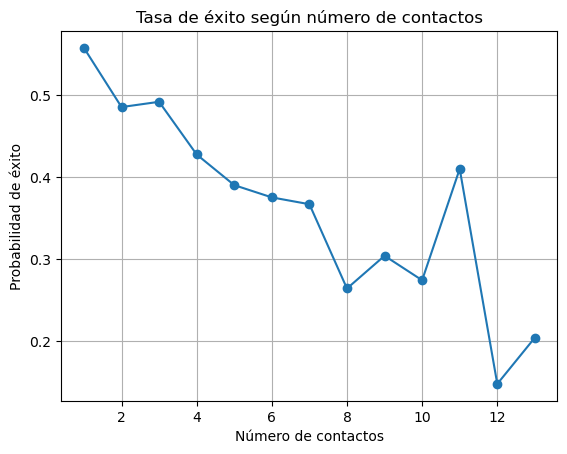

In [17]:
success_rate['yes'].plot(marker='o')
plt.title("Tasa de éxito según número de contactos")
plt.xlabel("Número de contactos")
plt.ylabel("Probabilidad de éxito")
plt.grid()
plt.show()

## **4- Agrupación de contactos**

In [18]:
def agrupar_contactos(x):
    if x <= 2:
        return "Bajo"
    elif x <= 5:
        return "Medio"
    else:
        return "Alto"

df['grupo_contacto'] = df['campaign'].apply(agrupar_contactos)

## **6- Visualización agrupada**

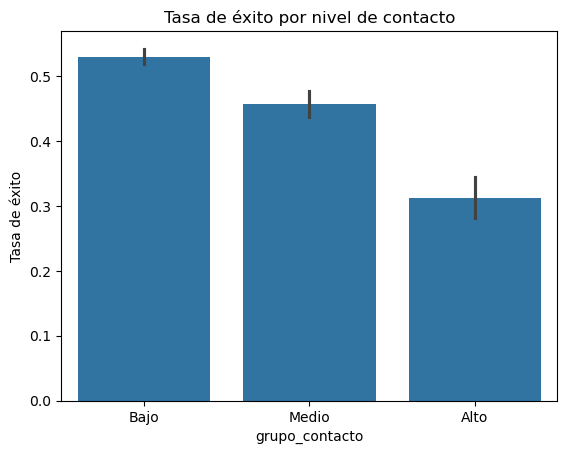

In [19]:
sns.barplot(
    data=df,
    x='grupo_contacto',
    y=(df['deposit'] == 'yes').astype(int)
)

plt.title("Tasa de éxito por nivel de contacto")
plt.ylabel("Tasa de éxito")
plt.show()

## **7- Visualización del análisis de distribución**

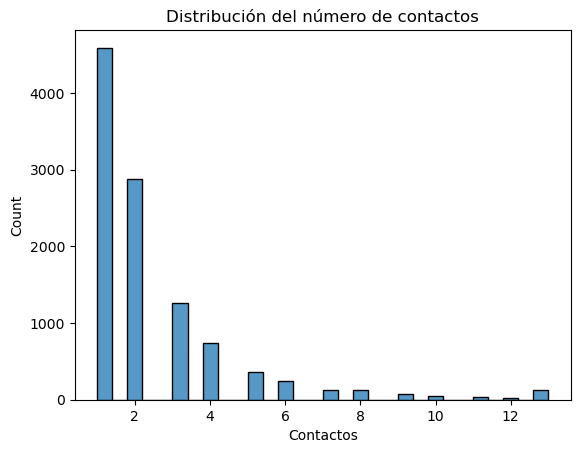

In [20]:
sns.histplot(df['campaign'], bins=30)
plt.title("Distribución del número de contactos")
plt.xlabel("Contactos")
plt.show()

## **8- Conclusiones**

- Se observa una relación negativa entre el número de contactos y la tasa de éxito.
- Los clientes con pocos contactos presentan mayor probabilidad de conversión, mientras que un exceso de contactos reduce la eficacia de la campaña, indicando un posible efecto de saturación.

## **9- Recomendaciones**

- Se recomienda optimizar la frecuencia de contacto priorizando la calidad sobre la cantidad, y evitando sobrecontactar a los clientes para maximizar la tasa de conversión.